# 09 · Water quality: from optical signal to a testable hypothesis

**Time:** 35 minutes · **Audience:** undergraduate / introductory graduate GIS and Earth science.

**By the end:** Follow a moving reflectance feature and identify what calibration is needed to discuss water quality.

[Run in JupyterLite](https://jltobias.github.io/JupyterLite-zarr-sql-views/lite/lab/index.html?path=09_water_quality.ipynb) · [Earth lab](https://jltobias.github.io/JupyterLite-zarr-sql-views/lab/) · [Sources and licenses](https://jltobias.github.io/JupyterLite-zarr-sql-views/book/credits.html)

Run cells from top to bottom with **Shift+Enter**. The first kernel start downloads Python WebAssembly packages.
The bundled exercises need no data-service account. Save a copy with **File → Save and Export Notebook As** before clearing browser storage.

![Four-stage workflow: STAC discovery, Zarr reading, SQL selection, linked views](assets/pipeline.svg)

In [1]:
from course import *
import numpy as np
import matplotlib.pyplot as plt
print('Ready: Python + NumPy + local teaching data')

Ready: Python + NumPy + local teaching data


## 1. Follow a synthetic plume

The grid uses Lake Victoria-area coordinates but invented red-band reflectance. It is not a satellite scene.
Reflectance is dimensionless. Sediment, algae, bottom reflectance, atmosphere, and viewing conditions can all influence optical signals.
A high value is not a pathogen measurement and cannot establish drinking-water safety.

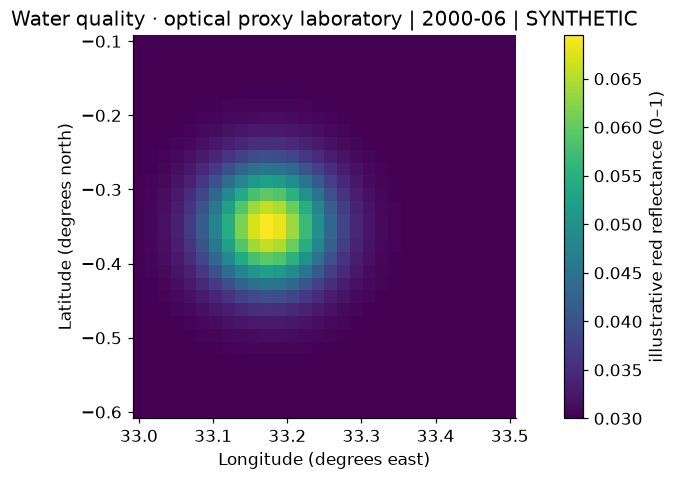

In [2]:
meta,red=load_cube('water')
map_slice(meta,red,5);plt.show()

## 2. Make a space–time section

A transect sacrifices one spatial dimension to make temporal movement easier to inspect.
Unlike a 3D cube it has no occlusion, but a different row could show a different story.

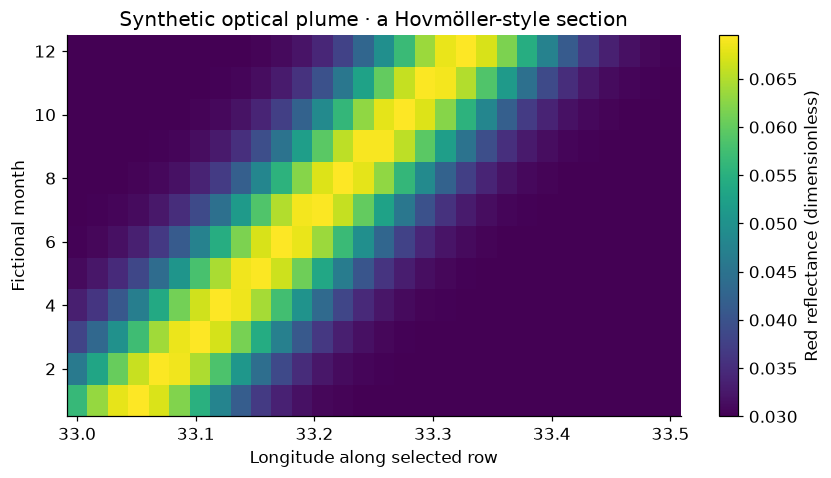

In [3]:
row=15
fig,ax=plt.subplots()
image=ax.pcolormesh(meta['lon'],range(1,13),red[:,row,:],shading='nearest',cmap='viridis')
ax.set(xlabel='Longitude along selected row',ylabel='Fictional month',title='Synthetic optical plume · a Hovmöller-style section')
fig.colorbar(image,ax=ax,label='Red reflectance (dimensionless)');plt.show()

## 3. Export candidate locations for validation

Treat a threshold as a screening hypothesis. Plan paired in-situ sampling and quality control to evaluate the hypothesis.
For real Earth observation practice, discover Sentinel-2 surface-reflectance assets through DE Africa STAC and inspect masks and scaling.
The WOfS dataset used elsewhere in this course measures water presence, not water quality.

In [4]:
print('Exported candidate cell-months:',export_geojson(meta,red,'optical-candidates.geojson',threshold=.06))
lab('water','cube')

Exported candidate cell-months: 210


## Try it yourself

Move the transect and threshold. Propose a calibration study with a response variable, paired samples, and an independent validation set.

## Check your reasoning

A defensible model needs field measurements and uncertainty estimates. A bright plume alone cannot diagnose its cause or safety consequences.

## Evidence journal

Write four sentences: **what I observed; how I calculated it; what this cannot establish; what evidence I need next**.
For any figure you reuse, retain its units, date or scenario, data origin, transformations, and attribution.

## Sources and credit

- [Digital Earth Africa WOfS specifications and limitations](https://docs.digitalearthafrica.org/en/latest/data_specs/Landsat_WOfS_specs.html), CC BY 4.0 data.
- [Digital Earth Africa direct data access](https://docs.digitalearthafrica.org/en/latest/platform_tools/index_direct_access.html)

Teaching adaptation of [dzole0311/zarr-sql-views](https://github.com/dzole0311/zarr-sql-views), ISC.
Original teaching code and prose: JupyterLite-zarr-sql-views contributors, ISC. Data keep their separate licenses.